# Experiment B: Residualized Per-Source CAA Analysis

## Motivation

In the baseline per-source analysis, emotion label separability from individual CAA vectors is above chance but weak. The likely reason: the **common emotionalization direction** $g$ — the shared "neutral → emotional" shift — dominates every individual delta vector $\delta[n,e]$, hiding emotion-specific differences.

After removing $g$ from each delta, we test whether **emotion-specific** signal becomes more decodable.

## Method

1. Load per-source deltas: $\delta[n,e] = h_{\text{emotion}}[n,e] - h_{\text{base}}[n]$ (pooled over intensities)
2. Compute common direction from **global** pooled CAA: $g = \text{unit}(\bar{c})$ where $\bar{c} = \frac{1}{|E|}\sum_e c_e$
3. Residualize: $\delta^\text{resid}[n,e] = \delta[n,e] - (\delta[n,e] \cdot g)\, g$
4. Re-run per-source analyses on both original and residualized vectors

## Key question

Does removing $g$ improve emotion label decodability?
- **Yes** → the common direction was masking emotion-specific structure.
- **No** → emotion-specific signal may be weak, distributed differently, or require other approaches.

In [1]:
from __future__ import annotations

import gc
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import GroupKFold

warnings.filterwarnings('ignore')

REPO_ROOT    = Path('../..').resolve()
ACT_DIR      = REPO_ROOT / 'activation' / 'emotion_rewrites'
EMO_NPY      = ACT_DIR / 'emotion_intensity_residual_stream.npy'
EMO_INFO     = ACT_DIR / 'emotion_intensity_residual_stream_info.json'
NEUTRAL_NPY  = ACT_DIR / 'neutral_paraphrase_residual_stream.npy'
NEUTRAL_INFO = ACT_DIR / 'neutral_paraphrase_residual_stream_info.json'
CAA_PATH     = ACT_DIR / 'caa_emotion_directions.npz'
CAA_INFO     = ACT_DIR / 'caa_emotion_directions_info.json'
OUT_DIR      = REPO_ROOT / 'analysis' / 'caa' / 'residualized_per_source'
OUT_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY_LAYER = 13
MAX_SOURCES   = 1200    # safer default to reduce OOM risk
SEED          = 42
DIMS_TO_TEST  = [2, 4, 8, 16, 32, 64]

rng = np.random.default_rng(SEED)
sns.set_context('notebook')
sns.set_style('whitegrid')


In [2]:
with open(EMO_INFO)     as f: EMO_META     = json.load(f)
with open(NEUTRAL_INFO) as f: NEUTRAL_META = json.load(f)
with open(CAA_INFO)     as f: CAA_META     = json.load(f)

# Validate source_id alignment
assert EMO_META['source_ids'] == NEUTRAL_META['source_ids'], (
    "source_ids mismatch between emotion and neutral-paraphrase info files. "
    "Re-extract activations with matching source_id order."
)

EMOTION_ORDER   = EMO_META['emotion_order']
INTENSITY_ORDER = EMO_META['intensity_order']
LAYER_INDICES   = EMO_META['layer_indices']
N_EMO  = len(EMOTION_ORDER)
N_INT  = len(INTENSITY_ORDER)
LI_MAP = {l: i for i, l in enumerate(LAYER_INDICES)}
EMO_POS = {e: i for i, e in enumerate(EMOTION_ORDER)}

EMO_SHAPE     = tuple(EMO_META['shape'])        # (N, 8, 3, 6, 4096)
NEUTRAL_SHAPE = tuple(NEUTRAL_META['shape'])    # (N, 6, 4096)
N_TOTAL, _, _, N_LAY, D = EMO_SHAPE

# Memory-map both arrays
ACT_EMO     = np.memmap(str(EMO_NPY),     dtype='float32', mode='r', shape=EMO_SHAPE)
ACT_NEUTRAL = np.memmap(str(NEUTRAL_NPY), dtype='float32', mode='r', shape=NEUTRAL_SHAPE)

# Stable source subsample
if N_TOTAL > MAX_SOURCES:
    SRC_IDX = np.sort(rng.choice(N_TOTAL, size=MAX_SOURCES, replace=False))
else:
    SRC_IDX = np.arange(N_TOTAL)
N_SUB = len(SRC_IDX)

# Global pooled CAA
caa_data   = np.load(CAA_PATH)
CAA_POOLED = caa_data['caa_pooled']  # (8, 6, 4096) unit-normed

print(f'ACT_EMO shape: {EMO_SHAPE}')
print(f'Using {N_SUB}/{N_TOTAL} sources. D={D}')
print(f'Emotions: {EMOTION_ORDER}')
print(f'Layers:   {LAYER_INDICES}')


ACT_EMO shape: (22782, 8, 3, 6, 4096)
Using 1200/22782 sources. D=4096
Emotions: ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']
Layers:   [8, 10, 13, 16, 19, 22]


In [3]:
# -- Helpers ------------------------------------------------------------------

def unit(v: np.ndarray) -> np.ndarray:
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return v / (n + 1e-12)

def participation_ratio(s: np.ndarray) -> float:
    lam = s.astype(np.float64) ** 2
    return float(lam.sum() ** 2 / (lam ** 2).sum())

def load_per_source_delta(layer: int, pool_intensity: bool = True) -> np.ndarray:
    """
    Compute per-source CAA vectors:
        delta[n, e, i, l] = h_emotion[n, e, i, l] - h_neutral[n, l]
    Memory-safe path pools one emotion at a time to avoid giant temporary arrays.

    Returns:
        If pool_intensity=True:  (N_SUB, N_EMO, D) averaged over intensities
        If pool_intensity=False: (N_SUB, N_EMO, N_INT, D)
    """
    li = LI_MAP[layer]
    h_neutral = np.asarray(ACT_NEUTRAL[SRC_IDX, li, :], dtype=np.float32)  # (N_SUB, D)

    if pool_intensity:
        result = np.empty((N_SUB, N_EMO, D), dtype=np.float32)
        for e_idx in range(N_EMO):
            block = np.asarray(ACT_EMO[SRC_IDX, e_idx, :, li, :], dtype=np.float32)  # (N_SUB, N_INT, D)
            block -= h_neutral[:, None, :]
            result[:, e_idx, :] = block.mean(axis=1)
            del block
            gc.collect()
        del h_neutral
        gc.collect()
        return result

    # Full tensor path is larger; keep for completeness.
    delta = np.asarray(ACT_EMO[SRC_IDX, :, :, li, :], dtype=np.float32)
    delta -= h_neutral[:, None, None, :]
    del h_neutral
    gc.collect()
    return delta

def get_global_caa(layer: int) -> np.ndarray:
    """Return (N_EMO, D) unit-normed global pooled CAA at layer."""
    return CAA_POOLED[:, LI_MAP[layer], :]

def compute_g(layer: int) -> np.ndarray:
    """Compute unit-normed common emotionalization direction at layer."""
    c = get_global_caa(layer)   # (8, D) unit-normed
    g_raw = c.mean(axis=0)      # (D,)
    return g_raw / (np.linalg.norm(g_raw) + 1e-12)

def residualize_vectors(X: np.ndarray, g: np.ndarray) -> np.ndarray:
    """
    Remove projection onto g from each row of X.
    X: (..., D), g: (D,) unit-normed.
    Returns residualized array of same shape.
    """
    proj = (X @ g)[..., None]          # (..., 1)
    return X - proj * g                # (..., D)

EMO_COLORS = {
    'joy': '#FFD700', 'trust': '#3cb44b', 'fear': '#008080',
    'surprise': '#4363d8', 'sadness': '#1e90ff', 'disgust': '#800080',
    'anger': '#e6194b', 'anticipation': '#f58231',
}

print('Helpers defined (streaming delta loader enabled).')


Helpers defined (streaming delta loader enabled).


## 1. Per-source consistency: before and after residualization

For each source $n$ and emotion $e$, compute:
- $\cos(\delta[n,e],\, c_e)$ — consistency with global CAA direction (original)
- $\cos(\delta^\text{resid}[n,e],\, c^\text{resid}_e)$ — consistency after removing $g$

The original consistency measures whether each source's delta points in the global CAA direction. The residualized consistency measures whether, after removing the shared "emotionalization" component, each source still shows the same emotion-specific direction.

In [4]:
print(f'Loading per-source delta at layer {PRIMARY_LAYER} ...')
delta = load_per_source_delta(PRIMARY_LAYER, pool_intensity=True)  # (N_SUB, 8, D)
g     = compute_g(PRIMARY_LAYER)                                    # (D,)
g_caa = get_global_caa(PRIMARY_LAYER)                              # (8, D) unit-normed

# Residualize individual deltas and global CAA
delta_resid = residualize_vectors(delta, g)                # (N_SUB, 8, D)
g_caa_resid = residualize_vectors(g_caa, g)               # (8, D)

# Cosine of each source with global direction (original)
delta_u      = unit(delta)            # (N_SUB, 8, D)
cos_orig     = np.einsum('ned,ed->ne', delta_u, g_caa)    # (N_SUB, 8)
del delta_u; gc.collect()

# Cosine of each residualized source with residualized global direction
delta_resid_u = unit(delta_resid)     # (N_SUB, 8, D)
g_caa_resid_u = unit(g_caa_resid)    # (8, D)
cos_resid     = np.einsum('ned,ed->ne', delta_resid_u, g_caa_resid_u)  # (N_SUB, 8)
del delta_resid_u, g_caa_resid_u, g_caa_resid; gc.collect()

df_cos_orig  = pd.DataFrame(cos_orig,  columns=EMOTION_ORDER)
df_cos_resid = pd.DataFrame(cos_resid, columns=EMOTION_ORDER)
del cos_orig, cos_resid; gc.collect()

print(f'\nOriginal consistency (mean per emotion):')
print(df_cos_orig.mean().round(4).to_string())
print(f'\nResidual consistency (mean per emotion):')
print(df_cos_resid.mean().round(4).to_string())


Loading per-source delta at layer 13 ...

Original consistency (mean per emotion):
joy             0.8526
trust           0.8512
fear            0.8510
surprise        0.8538
sadness         0.8541
disgust         0.8513
anger           0.8519
anticipation    0.8553

Residual consistency (mean per emotion):
joy             0.2038
trust           0.2129
fear            0.1690
surprise        0.2250
sadness         0.1434
disgust         0.1585
anger           0.1801
anticipation    0.1842


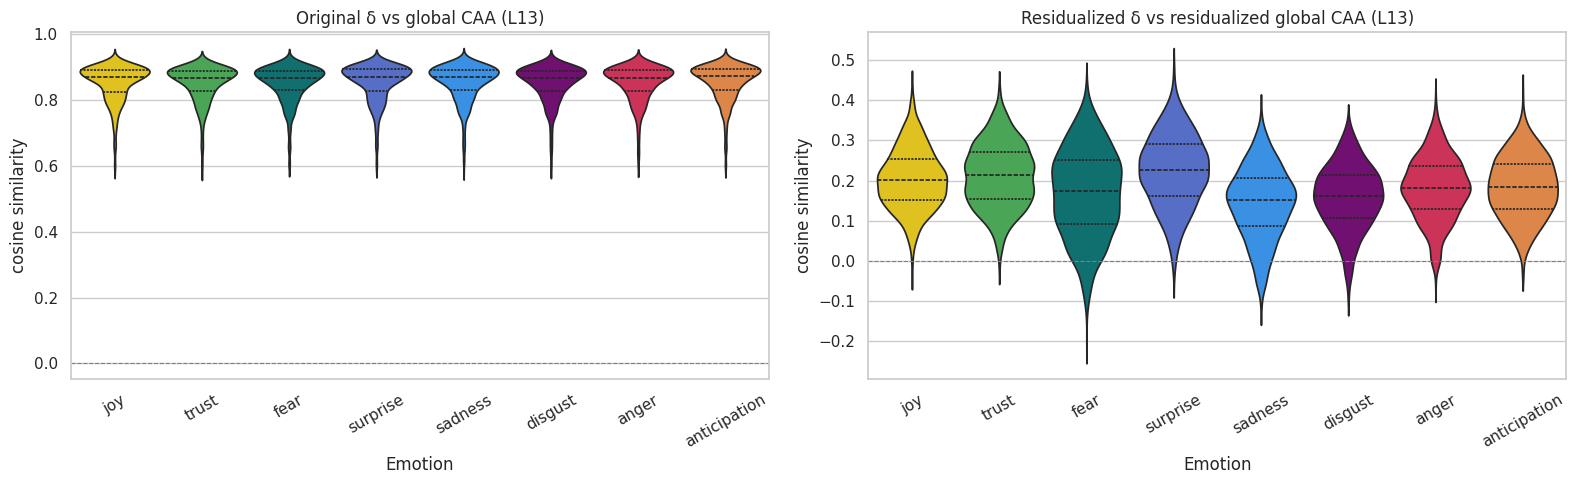

In [5]:
# Save summaries
summary_orig  = df_cos_orig.describe().loc[['mean','std','25%','50%','75%']]
summary_resid = df_cos_resid.describe().loc[['mean','std','25%','50%','75%']]
summary_orig.to_csv(OUT_DIR  / f'consistency_orig_L{PRIMARY_LAYER}.csv')
summary_resid.to_csv(OUT_DIR / f'consistency_resid_L{PRIMARY_LAYER}.csv')

# Violin comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, df, title in [
    (axes[0], df_cos_orig,  f'Original δ vs global CAA (L{PRIMARY_LAYER})'),
    (axes[1], df_cos_resid, f'Residualized δ vs residualized global CAA (L{PRIMARY_LAYER})'),
]:
    melt = df.melt(var_name='emotion', value_name='cosine')
    sns.violinplot(data=melt, x='emotion', y='cosine', order=EMOTION_ORDER,
                   inner='quartile', ax=ax, palette=EMO_COLORS)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Emotion'); ax.set_ylabel('cosine similarity')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUT_DIR / f'consistency_violin_L{PRIMARY_LAYER}.png', bbox_inches='tight')
plt.show()

## 2. Emotion label separability: original vs residualized

Build classification datasets:
- $X_{\text{orig}} = \{\delta[n,e]\}$, $y = $ emotion label
- $X_{\text{resid}} = \{\delta^\text{resid}[n,e]\}$, $y = $ emotion label

Use **source-held-out cross-validation** (GroupKFold by source ID) with logistic regression at varying PCA dimensions. Report balanced accuracy.

Chance level = $1/8 = 0.125$.

In [6]:
from sklearn.decomposition import TruncatedSVD

CHANCE = 1.0 / N_EMO

def run_classification(X_3d, y_all, groups, dims_to_test, label):
    """
    Memory-safe classification with source-held-out GroupKFold.
    Uses randomized TruncatedSVD on float32 instead of full PCA to reduce RAM spikes.
    """
    gkf = GroupKFold(n_splits=5)
    rows = []

    # Flatten lazily; keep float32 to avoid hidden float64 expansion.
    X_flat = X_3d.reshape(-1, D).astype(np.float32, copy=False)

    for n_dims in dims_to_test:
        n_dims = min(n_dims, X_flat.shape[1], X_flat.shape[0] - 1)
        svd = TruncatedSVD(n_components=n_dims, random_state=SEED)
        X_proj = svd.fit_transform(X_flat).astype(np.float32, copy=False)

        accs = []
        for train_idx, test_idx in gkf.split(X_proj, y_all, groups):
            clf = LogisticRegression(max_iter=500, C=1.0, random_state=SEED)
            clf.fit(X_proj[train_idx], y_all[train_idx])
            pred = clf.predict(X_proj[test_idx])
            accs.append(balanced_accuracy_score(y_all[test_idx], pred))

        rows.append({
            'condition': label,
            'n_dims': n_dims,
            'bal_acc': float(np.mean(accs)),
            'std': float(np.std(accs)),
        })
        print(f'  {label:12s} dims={n_dims:3d}  acc={np.mean(accs):.4f} ± {np.std(accs):.4f}')

        del X_proj, svd
        gc.collect()

    return rows

# Labels and groups (source-held-out CV)
y_all = np.tile(np.arange(N_EMO), N_SUB)      # (N_SUB*8,)
groups = np.repeat(np.arange(N_SUB), N_EMO)   # (N_SUB*8,)

print(f'Dataset (per condition): {(N_SUB * N_EMO, D)}, chance={CHANCE:.3f}')
print(f'Running classification at layer {PRIMARY_LAYER} with memory-safe SVD...')
rows_clf = []
rows_clf += run_classification(delta, y_all, groups, DIMS_TO_TEST, 'original')
rows_clf += run_classification(delta_resid, y_all, groups, DIMS_TO_TEST, 'residualized')

df_clf = pd.DataFrame(rows_clf)
df_clf.to_csv(OUT_DIR / f'classification_L{PRIMARY_LAYER}.csv', index=False)
print('\nDone.')

Dataset (per condition): (9600, 4096), chance=0.125
Running classification at layer 13 with memory-safe SVD...
  original     dims=  2  acc=0.1331 ± 0.0025
  original     dims=  4  acc=0.1370 ± 0.0022
  original     dims=  8  acc=0.2414 ± 0.0061
  original     dims= 16  acc=0.5194 ± 0.0150
  original     dims= 32  acc=0.7370 ± 0.0084
  original     dims= 64  acc=0.8215 ± 0.0094
  residualized dims=  2  acc=0.1323 ± 0.0022
  residualized dims=  4  acc=0.1500 ± 0.0039
  residualized dims=  8  acc=0.3165 ± 0.0049
  residualized dims= 16  acc=0.5241 ± 0.0119
  residualized dims= 32  acc=0.7474 ± 0.0093
  residualized dims= 64  acc=0.8233 ± 0.0112

Done.


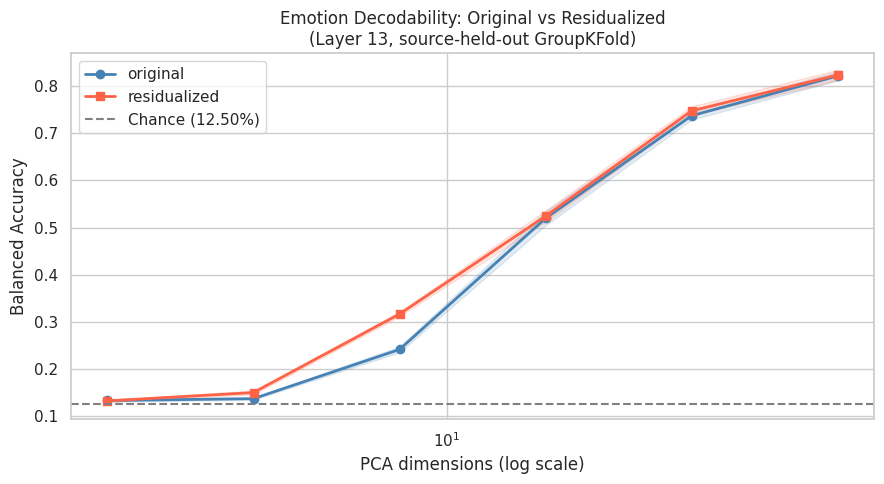

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

for condition, color, marker in [
    ('original',     'steelblue', 'o'),
    ('residualized', 'tomato',    's'),
]:
    sub = df_clf[df_clf.condition == condition]
    ax.plot(sub['n_dims'], sub['bal_acc'], marker=marker, label=condition,
            color=color, linewidth=2)
    ax.fill_between(sub['n_dims'],
                    sub['bal_acc'] - sub['std'],
                    sub['bal_acc'] + sub['std'],
                    alpha=0.15, color=color)

ax.axhline(CHANCE, color='gray', linestyle='--', label=f'Chance ({CHANCE:.2%})')
ax.set_xscale('log')
ax.set_xlabel('PCA dimensions (log scale)')
ax.set_ylabel('Balanced Accuracy')
ax.set_title(f'Emotion Decodability: Original vs Residualized\n'
             f'(Layer {PRIMARY_LAYER}, source-held-out GroupKFold)')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / f'classification_L{PRIMARY_LAYER}.png', bbox_inches='tight')
plt.show()

## 3. 2D Visualization: individual CAA vectors before and after residualization

Project individual per-source delta vectors onto the top 2 PCA dimensions of the **residualized** space. If emotion-specific structure is present, emotion clouds should separate more clearly after removing $g$.

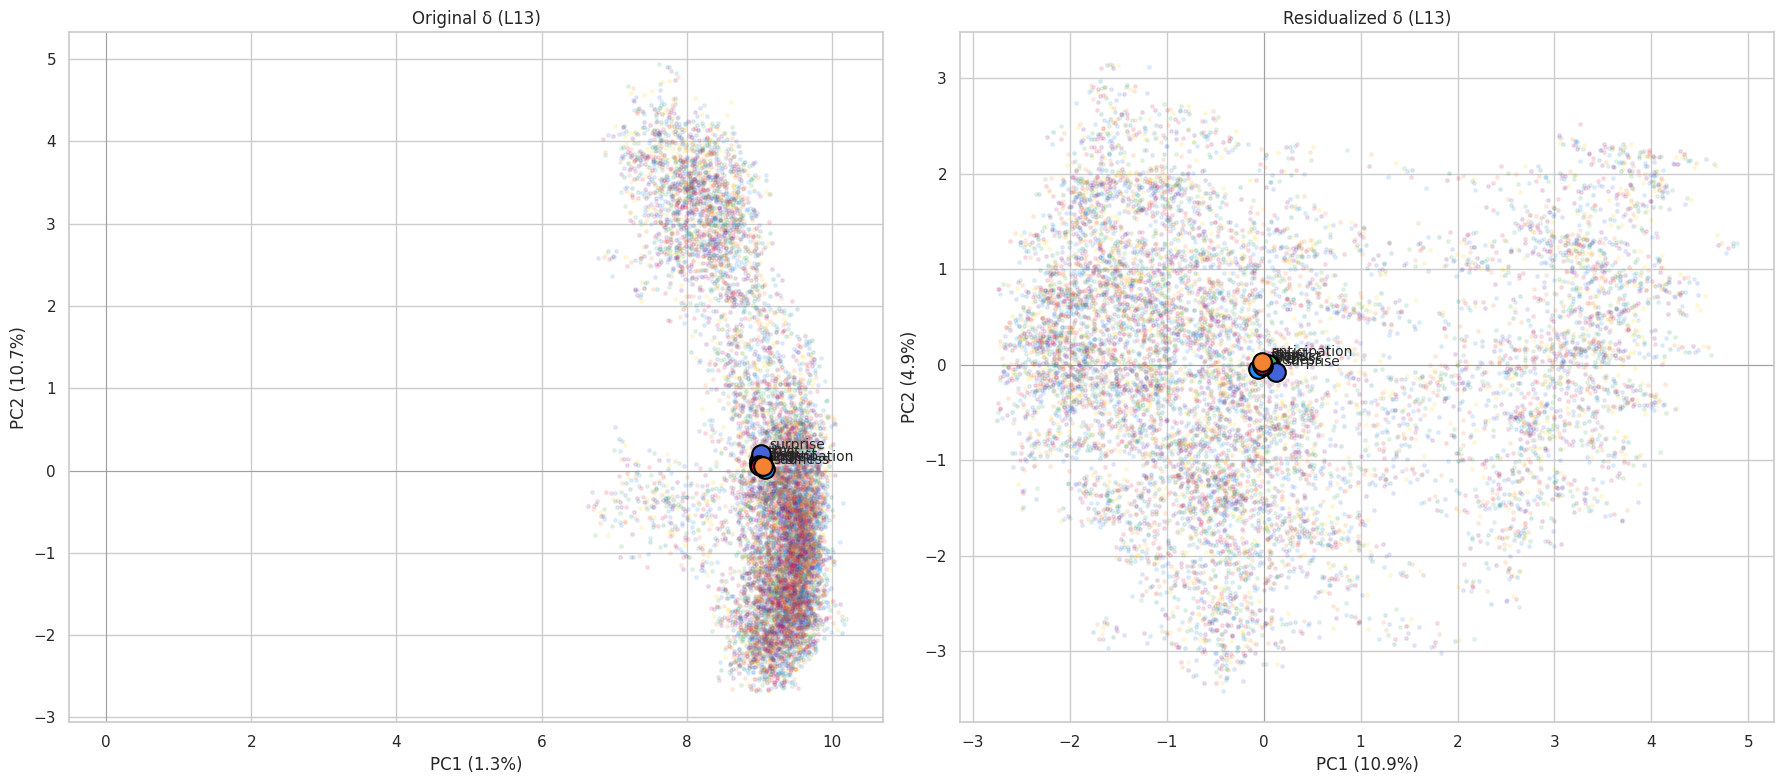

delta freed.


In [8]:
from sklearn.decomposition import TruncatedSVD

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

conditions = [
    (axes[0], delta,        f'Original δ (L{PRIMARY_LAYER})'),
    (axes[1], delta_resid,  f'Residualized δ (L{PRIMARY_LAYER})'),
]

for ax, X_3d, title in conditions:
    X_flat = X_3d.reshape(-1, D)          # view only, no copy
    svd = TruncatedSVD(n_components=2, random_state=SEED)
    proj = svd.fit_transform(X_flat)      # (N_SUB*8, 2)
    evr  = svd.explained_variance_ratio_
    del svd, X_flat; gc.collect()         # free SVD buffers before reshape

    proj_mat  = proj.reshape(N_SUB, N_EMO, 2)
    centroids = proj_mat.mean(axis=0)

    for e, emo in enumerate(EMOTION_ORDER):
        c = EMO_COLORS.get(emo, 'gray')
        ax.scatter(proj_mat[:, e, 0], proj_mat[:, e, 1],
                   alpha=0.12, s=6, color=c, label=None)

    for e, emo in enumerate(EMOTION_ORDER):
        c = EMO_COLORS.get(emo, 'gray')
        ax.scatter(centroids[e, 0], centroids[e, 1],
                   s=180, color=c, edgecolors='black', linewidths=1.5, zorder=5)
        ax.annotate(emo, (centroids[e, 0], centroids[e, 1]),
                    textcoords='offset points', xytext=(6, 4), fontsize=10)

    ax.set_xlabel(f'PC1 ({evr[0]:.1%})')
    ax.set_ylabel(f'PC2 ({evr[1]:.1%})')
    ax.set_title(title, fontsize=12)
    ax.axhline(0, color='gray', linewidth=0.4)
    ax.axvline(0, color='gray', linewidth=0.4)
    del proj, proj_mat, centroids; gc.collect()

plt.tight_layout()
plt.savefig(OUT_DIR / f'pca_2d_individual_L{PRIMARY_LAYER}.png', bbox_inches='tight')
plt.show()

del delta; gc.collect()
print('delta freed.')

## 4. Confusion matrix at best PCA dimension (primary layer)

Use the dimensionality with highest balanced accuracy from the residualized condition, and show the confusion matrix for the last fold.

Best dims for residualized: 64  (acc=0.8233)


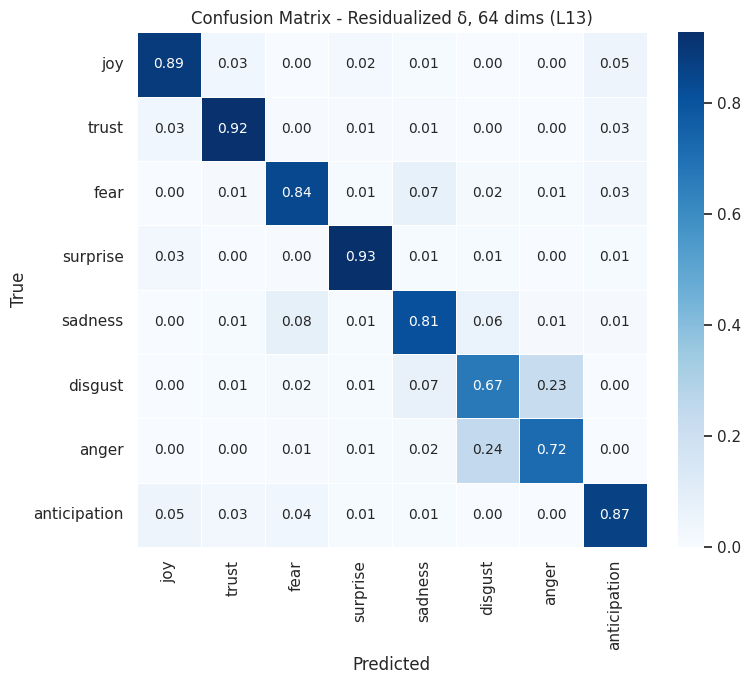

delta_resid freed.


In [9]:
from sklearn.decomposition import TruncatedSVD

# Find best dimensionality for residualized condition
best_row = df_clf[df_clf.condition == 'residualized'].sort_values('bal_acc', ascending=False).iloc[0]
best_dims = int(best_row['n_dims'])
print(f'Best dims for residualized: {best_dims}  (acc={best_row["bal_acc"]:.4f})')

# Build residualized feature matrix on demand
X_resid_flat = delta_resid.reshape(-1, D).astype(np.float32, copy=False)

# Fold-wise SVD to reduce peak memory vs fitting on the full matrix at once
gkf = GroupKFold(n_splits=5)
y_true_all, y_pred_all = [], []

for train_idx, test_idx in gkf.split(X_resid_flat, y_all, groups):
    svd = TruncatedSVD(n_components=best_dims, random_state=SEED)
    Xtr = svd.fit_transform(X_resid_flat[train_idx]).astype(np.float32, copy=False)
    Xte = svd.transform(X_resid_flat[test_idx]).astype(np.float32, copy=False)

    clf = LogisticRegression(max_iter=500, C=1.0, random_state=SEED)
    clf.fit(Xtr, y_all[train_idx])
    pred = clf.predict(Xte)

    y_true_all.extend(y_all[test_idx])
    y_pred_all.extend(pred)

    del svd, Xtr, Xte, clf, pred
    gc.collect()

del X_resid_flat; gc.collect()

cm = confusion_matrix(y_true_all, y_pred_all)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    pd.DataFrame(cm_norm, index=EMOTION_ORDER, columns=EMOTION_ORDER),
    annot=True, fmt='.2f', cmap='Blues', ax=ax,
    linewidths=0.5, annot_kws={'size': 10},
)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix - Residualized δ, {best_dims} dims (L{PRIMARY_LAYER})')
plt.tight_layout()
plt.savefig(OUT_DIR / f'confusion_matrix_resid_L{PRIMARY_LAYER}.png', bbox_inches='tight')
plt.show()

pd.DataFrame(cm_norm, index=EMOTION_ORDER, columns=EMOTION_ORDER).to_csv(
    OUT_DIR / f'confusion_matrix_resid_L{PRIMARY_LAYER}.csv'
 )

# delta_resid no longer needed; section 5 loads fresh per-layer data
del delta_resid; gc.collect()
print('delta_resid freed.')


## 5. Layer-wise classification sweep

Run the same classification at each layer, comparing original vs residualized at a fixed PCA dimension of 16.

In [10]:
from sklearn.decomposition import TruncatedSVD

FIXED_DIMS = 16
gkf = GroupKFold(n_splits=5)

rows_layer = []
for layer in LAYER_INDICES:
    print(f'Layer {layer}...')
    g_l = compute_g(layer)                                    # (D,)
    dp = load_per_source_delta(layer, pool_intensity=True)   # (N_SUB, 8, D)
    dp_r = residualize_vectors(dp, g_l)                      # (N_SUB, 8, D)

    # Consistency
    g_caa_l = get_global_caa(layer)                          # (8, D)
    g_caa_r = residualize_vectors(g_caa_l, g_l)
    cos_o = np.einsum('ned,ed->ne', unit(dp), g_caa_l).mean()
    cos_r = np.einsum('ned,ed->ne', unit(dp_r), unit(g_caa_r)).mean()

    # Classification at fixed dims (memory-safe randomized SVD)
    y_l = np.tile(np.arange(N_EMO), N_SUB)
    grp = np.repeat(np.arange(N_SUB), N_EMO)

    for cond, X3d in [('original', dp), ('residualized', dp_r)]:
        X_flat = X3d.reshape(-1, D).astype(np.float32, copy=False)
        dims = min(FIXED_DIMS, X_flat.shape[1], X_flat.shape[0] - 1)
        svd = TruncatedSVD(n_components=dims, random_state=SEED)
        Xp = svd.fit_transform(X_flat).astype(np.float32, copy=False)

        accs = []
        for tr, te in gkf.split(Xp, y_l, grp):
            clf = LogisticRegression(max_iter=500, C=1.0, random_state=SEED)
            clf.fit(Xp[tr], y_l[tr])
            accs.append(balanced_accuracy_score(y_l[te], clf.predict(Xp[te])))

        rows_layer.append({
            'layer': layer,
            'condition': cond,
            'bal_acc': float(np.mean(accs)),
            'std': float(np.std(accs)),
            'mean_consistency': float(cos_o if cond == 'original' else cos_r),
        })

        del X_flat, Xp, svd
        gc.collect()

    del dp, dp_r, g_caa_l, g_caa_r
    gc.collect()

df_layer = pd.DataFrame(rows_layer)
df_layer.to_csv(OUT_DIR / 'classification_by_layer.csv', index=False)
print('Done.')


Layer 8...
Layer 10...
Layer 13...
Layer 16...
Layer 19...
Layer 22...
Done.


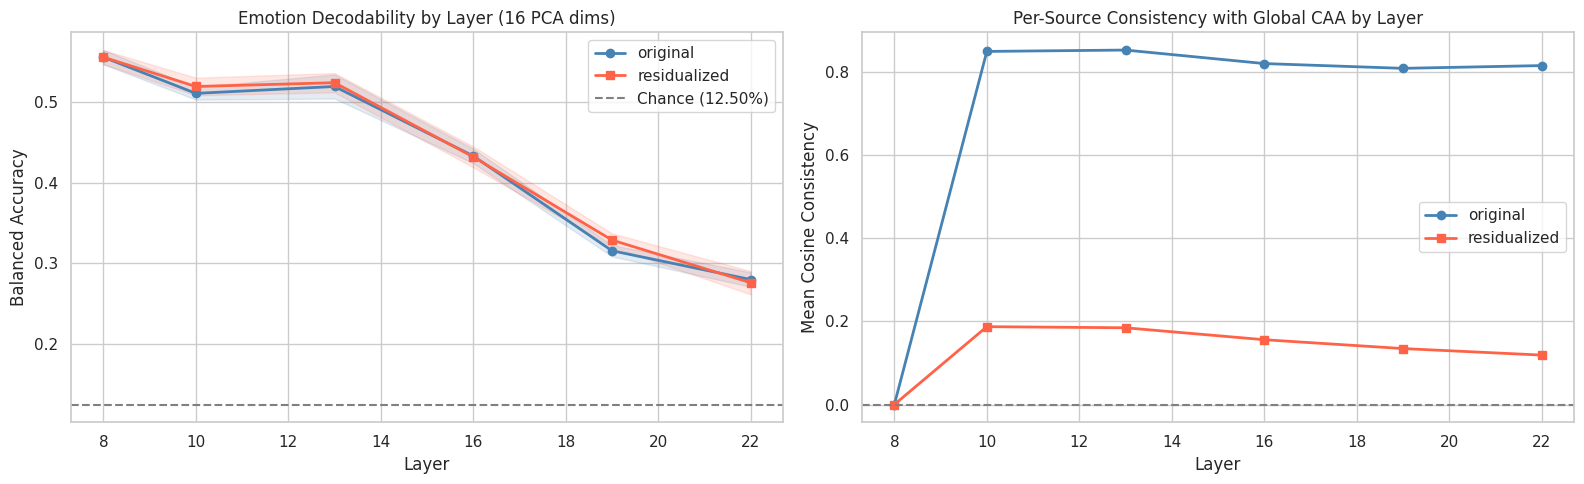

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for condition, color, marker in [
    ('original',     'steelblue', 'o'),
    ('residualized', 'tomato',    's'),
]:
    sub = df_layer[df_layer.condition == condition]
    axes[0].plot(sub['layer'], sub['bal_acc'], marker=marker, label=condition,
                 color=color, linewidth=2)
    axes[0].fill_between(sub['layer'],
                          sub['bal_acc'] - sub['std'],
                          sub['bal_acc'] + sub['std'],
                          alpha=0.15, color=color)
    axes[1].plot(sub['layer'], sub['mean_consistency'], marker=marker,
                 label=condition, color=color, linewidth=2)

axes[0].axhline(CHANCE, color='gray', linestyle='--', label=f'Chance ({CHANCE:.2%})')
axes[0].set_xlabel('Layer'); axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_title(f'Emotion Decodability by Layer ({FIXED_DIMS} PCA dims)')
axes[0].legend()

axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_xlabel('Layer'); axes[1].set_ylabel('Mean Cosine Consistency')
axes[1].set_title('Per-Source Consistency with Global CAA by Layer')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'classification_by_layer.png', bbox_inches='tight')
plt.show()

## Summary

Key outputs saved to `analysis/caa/residualized_per_source/`:
- `consistency_orig_L{layer}.csv` — per-source consistency statistics (original)
- `consistency_resid_L{layer}.csv` — per-source consistency statistics (residualized)
- `classification_L{layer}.csv` — balanced accuracy by PCA dimension
- `confusion_matrix_resid_L{layer}.csv` — confusion matrix (residualized)
- `classification_by_layer.csv` — layer-wise classification sweep
- PNG plots

### Interpretation guide

| Observation | Interpretation |
|---|---|
| Residualized accuracy >> original accuracy | Common direction was masking emotion-specific signal |
| Both accuracies near chance | Emotion-specific signal is weak or not low-dimensional |
| Residualized consistency drops sharply | Individual deltas were nearly all aligned with $g$; emotion-specific residuals are noisy |
| 2D visualization shows separation after residualization | Recoverable emotion geometry exists in residual space |
| Confusion matrix: joy↔sadness confused frequently | These emotions may share residual directions |

**Note**: Classification using source-held-out GroupKFold ensures we are testing generalization to unseen source contexts, not memorization of source-specific patterns.